# 2026 COMP90042 Project

Self-contained final pipeline. In Colab, the recommended project layout is Google Drive `NLP_A3/` with data under `NLP_A3/data/` and this notebook under `NLP_A3/src/`. Locally, the notebook also supports the repository `data/` directory or an explicit `A3_DATA_DIR`. It generates every intermediate artifact itself and writes final outputs under the selected output directory.

Aligned stages:
1. four sparse candidate gates with fixed RRF fusion;
2. top64 context from MiniLM embedding inner product plus shallow factual hand features;
3. top3 evidence from CE plus embedding/source-rank fusion;
4. enhanced Context20 TF-IDF Logistic Regression classifier with rank and factual cue tokens.

Stage diagnostics are shown throughout the notebook; set `A3_VISUALIZE=0` to skip matplotlib plots.


# Readme

Recommended Colab layout:

```text
/content/drive/MyDrive/NLP_A3/
  data/
    train-claims.json
    dev-claims.json
    test-claims-unlabelled.json
    evidence.json
  src/
    GroupID_COMP90042_Project_2026.ipynb
    requirements.txt
    readme.md
  outputs/
    self_generated/
```

The notebook first looks for `A3_DATA_DIR`; otherwise it auto-detects the Drive path above, local repo `data/`, and common Colab upload folders. If Colab reports that Google Drive mount failed, mount Drive from the file pane or run `from google.colab import drive; drive.mount('/content/drive', force_remount=True)`, then rerun the first code cell. For test prediction set `A3_TARGET_FILE=test-claims-unlabelled.json`. No saved ranked artifacts, checkpoints, or repository code modules are read.


# 1.DataSet Processing


In [ ]:
from pathlib import Path
from dataclasses import dataclass
import gc, heapq, importlib.util, json, math, os, random, re, subprocess, sys, time
from collections import Counter, defaultdict
from functools import lru_cache

def ensure_notebook_dependencies():
    required = [
        ('transformers', 'transformers'),
        ('sentencepiece', 'sentencepiece'),
        ('safetensors', 'safetensors'),
    ]
    missing = [pkg for module, pkg in required if importlib.util.find_spec(module) is None]
    if missing:
        print('Installing missing packages:', missing)
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

ensure_notebook_dependencies()

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer, set_seed

NOTEBOOK_START = time.perf_counter()
SEED = 13
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)

@dataclass(frozen=True)
class RuntimeConfig:
    """Runtime-only switches for local and Colab execution.

    These fields only control where files are read/written and which target
    claims file is selected. They do not change model weights, ranking formulas,
    or classifier hyperparameters.
    """
    project_name: str = os.environ.get('A3_PROJECT_NAME', 'NLP_A3')
    target_file: str = os.environ.get('A3_TARGET_FILE', 'dev-claims.json')
    data_dir: str = os.environ.get('A3_DATA_DIR', '')
    output_dir: str = os.environ.get('A3_OUTPUT_DIR', '')
    visualize: bool = os.environ.get('A3_VISUALIZE', '1') != '0'
    save_artifacts: bool = os.environ.get('A3_SAVE_ARTIFACTS', '0') == '1'
    validate_equivalence: bool = os.environ.get('A3_VALIDATE_EQUIVALENCE', '0') == '1'
    smoke_mode: bool = os.environ.get('A3_SMOKE_MODE', '0') == '1'

CONFIG = RuntimeConfig()
VISUALIZE = CONFIG.visualize

def safe_exists(path):
    try:
        return Path(path).exists()
    except OSError:
        return False

def safe_is_dir(path):
    try:
        return Path(path).is_dir()
    except OSError:
        return False

def safe_glob(root, pattern):
    try:
        return sorted(Path(root).glob(pattern))
    except OSError:
        return []

def has_evidence_payload(root):
    root = Path(root)
    return safe_exists(root / 'evidence.json') or bool(safe_glob(root, 'evidence.json.part.*'))

def has_course_files(root):
    root = Path(root)
    return safe_exists(root / 'train-claims.json') and has_evidence_payload(root)

def materialize_evidence_json(root):
    root = Path(root)
    evidence_path = root / 'evidence.json'
    if safe_exists(evidence_path):
        return evidence_path
    parts = safe_glob(root, 'evidence.json.part.*')
    if not parts:
        return evidence_path
    print('Reconstructing evidence.json from', len(parts), 'parts in', root)
    with evidence_path.open('wb') as out:
        for part in parts:
            with part.open('rb') as src:
                out.write(src.read())
    return evidence_path

def project_name_candidates(config=CONFIG):
    names = [config.project_name, 'NLP_A3', 'NPL_A3', 'COMP90042_A3_colab_data']
    out = []
    for name in names:
        if name and name not in out:
            out.append(name)
    return out

def drive_roots():
    return [Path('/content/drive/MyDrive'), Path('/content/drive/My Drive')]

def google_drive_is_visible():
    return any(safe_is_dir(root) for root in drive_roots())

def maybe_mount_google_drive(config=CONFIG):
    if google_drive_is_visible() or not safe_exists('/content'):
        return
    try:
        from google.colab import drive
        print(f'Mounting Google Drive to find {config.project_name}/data...')
        drive.mount('/content/drive', force_remount=False)
    except Exception as exc:
        print('Google Drive mount retrying with force_remount=True after:', exc)
        try:
            drive.mount('/content/drive', force_remount=True)
        except Exception as exc2:
            print('Google Drive mount skipped:', exc2)
            print('If the data is on Drive, mount Drive from the Colab file pane or run drive.mount("/content/drive", force_remount=True), then rerun this cell.')

def candidate_data_dirs(config=CONFIG):
    cwd = Path.cwd()
    project_env = os.environ.get('A3_PROJECT_DIR', '')
    project_root = Path(project_env) if project_env else None
    project_names = project_name_candidates(config)
    candidates = [
        Path(config.data_dir) if config.data_dir else None,
        (project_root / 'data') if project_root else None,
        cwd,
        cwd / 'data',
        cwd.parent / 'data',
        cwd.parent.parent / 'data',
        cwd / 'submissions' / 'resource',
        cwd.parent / 'submissions' / 'resource',
        Path('/content'),
        Path('/content/colab_notebooks'),
    ]
    for root in drive_roots():
        for name in project_names:
            candidates.extend([root / name / 'data', root / name, root / name / 'src'])
    for name in project_names:
        candidates.extend([Path('/content') / name / 'data', Path('/content') / name])
    seen = set()
    for candidate in candidates:
        if candidate is None:
            continue
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        yield candidate

def find_course_base_dir(config=CONFIG):
    maybe_mount_google_drive(config)
    checked = []
    for candidate in candidate_data_dirs(config):
        checked.append(str(candidate))
        if has_course_files(candidate):
            return candidate
    raise FileNotFoundError(
        'Could not find train-claims.json and evidence.json. '
        'Put train-claims.json, the selected target claims JSON, and evidence.json or evidence.json.part.* '
        f'under /content/drive/MyDrive/{config.project_name}/data or /content/drive/MyDrive/{config.project_name}, '
        'upload them to the Colab file pane, or set A3_DATA_DIR explicitly. '
        'If Google Drive mount failed above, the notebook cannot see Drive files yet. Checked: ' + ', '.join(checked)
    )

def infer_output_dir(base_dir, config=CONFIG):
    if config.output_dir:
        return Path(config.output_dir)
    base_dir = Path(base_dir)
    # In the Drive project layout, keep generated files beside data rather than inside data/.
    if base_dir.name == 'data' and base_dir.parent.name == config.project_name:
        return base_dir.parent / 'outputs' / 'self_generated'
    return base_dir / 'outputs' / 'self_generated'

BASE_DIR = find_course_base_dir(CONFIG)
PROJECT_DIR = BASE_DIR.parent if BASE_DIR.name == 'data' and BASE_DIR.parent.name == CONFIG.project_name else BASE_DIR
OUTPUT_DIR = infer_output_dir(BASE_DIR, CONFIG)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_CLAIMS_PATH = BASE_DIR / 'train-claims.json'
TARGET_CLAIMS_PATH = BASE_DIR / CONFIG.target_file
EVIDENCE_PATH = materialize_evidence_json(BASE_DIR)

# Performance controls. By default, only final_predictions.json and run_summary.json are saved.
SAVE_ARTIFACTS = CONFIG.save_artifacts
VALIDATE_EQUIVALENCE = CONFIG.validate_equivalence

SMOKE_MODE = CONFIG.smoke_mode
SMOKE_TRAIN_CLAIMS = 120
SMOKE_TARGET_CLAIMS = 40
SMOKE_EVIDENCE_LIMIT = 80000

CANDIDATE_TOP_K = 500
TOP64_K = 64
FINAL_EVIDENCE_TOP_K = 3
CLASSIFIER_CONTEXT_TOP_K = 20
SPARSE_RRF_K = 500.0

EMBEDDING_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
CE_MODEL_NAME = 'cross-encoder/ms-marco-MiniLM-L6-v2'

BATCH_EMBED = 96
BATCH_CE = 64
MAX_EMBED_LENGTH = 128
MAX_CE_LENGTH = 256
EVIDENCE_TOKEN_BUDGET = 45

LABELS = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']
LABEL_TO_ID = {label:i for i,label in enumerate(LABELS)}
ID_TO_LABEL = {i:label for label,i in LABEL_TO_ID.items()}
TOKEN_RE = re.compile(r'[A-Za-z0-9]+')
STOPWORDS = set(ENGLISH_STOP_WORDS)
NEG_WORDS = {'not','no','never','without','less','fewer','decline','decrease','false'}

def load_json(path):
    with Path(path).open(encoding='utf-8') as f: return json.load(f)

def write_json(path, payload):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as f: json.dump(payload, f, ensure_ascii=False, indent=2)

def save_artifact(path, payload, force=False):
    if force or SAVE_ARTIFACTS:
        write_json(path, payload)

def limit_items(obj, n): return dict(list(obj.items())[:n])

def subset_evidence(evidence, *claim_sets, limit=0):
    if not limit or limit >= len(evidence): return evidence
    keep = set(list(evidence)[:limit])
    for claims in claim_sets:
        for claim in claims.values():
            keep.update(claim.get('evidences', []))
    return {eid:evidence[eid] for eid in evidence if eid in keep}

train_claims = load_json(TRAIN_CLAIMS_PATH)
target_claims = load_json(TARGET_CLAIMS_PATH)
evidence = load_json(EVIDENCE_PATH)
if SMOKE_MODE:
    train_claims = limit_items(train_claims, SMOKE_TRAIN_CLAIMS)
    target_claims = limit_items(target_claims, SMOKE_TARGET_CLAIMS)
    evidence = subset_evidence(evidence, train_claims, target_claims, limit=SMOKE_EVIDENCE_LIMIT)
    CANDIDATE_TOP_K = min(CANDIDATE_TOP_K, 120)
    TOP64_K = min(TOP64_K, 32)
print({'project_dir': str(PROJECT_DIR), 'data_dir': str(BASE_DIR), 'target_file': CONFIG.target_file, 'train_claims': len(train_claims), 'target_claims': len(target_claims), 'evidence': len(evidence), 'output_dir': str(OUTPUT_DIR), 'save_artifacts': SAVE_ARTIFACTS})


In [19]:
def has_labels(claims): return all('claim_label' in c for c in claims.values())

def evidence_f_score(gold, pred):
    gold=set(gold); pred=list(pred); hit=len(gold & set(pred))
    if not gold or not pred or not hit: return 0.0
    p=hit/len(pred); r=hit/len(gold)
    return 2*p*r/(p+r)

def retrieval_metrics(claims, pool, top_k):
    if not has_labels(claims): return {}
    f=[]; recalls=[]; hit_any=[]
    for cid, claim in claims.items():
        gold=set(claim.get('evidences', [])); pred=[r['evidence_id'] for r in pool.get(cid, [])[:top_k]]
        f.append(evidence_f_score(gold, pred))
        recalls.append(len(gold & set(pred))/len(gold) if gold else 0.0)
        hit_any.append(bool(gold & set(pred)))
    return {'evidence_f@'+str(top_k): float(np.mean(f)), 'macro_recall@'+str(top_k): float(np.mean(recalls)), 'hit_any@'+str(top_k): float(np.mean(hit_any))}

# Visualization helpers used by the stage diagnostics.
DISPLAY_LABELS = {
    'SUPPORTS': 'SUPPORTS',
    'REFUTES': 'REFUTES',
    'NOT_ENOUGH_INFO': 'NEI',
    'DISPUTED': 'DISPUTED',
}
STAGE_COLORS = ['#4c78a8', '#72b7b2', '#54a24b', '#c94f54', '#8064a8']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

def _maybe_show():
    if VISUALIZE:
        plt.show()
    else:
        plt.close()

def _annotate_bars(ax, bars, fmt='{:.1f}%'):
    ymax = max([bar.get_height() for bar in bars] + [0.0])
    pad = max(ymax * 0.025, 0.01)
    for bar in bars:
        value = bar.get_height()
        text = fmt.format(value * 100) if '%' in fmt else fmt.format(value)
        ax.text(bar.get_x() + bar.get_width() / 2, value + pad, text, ha='center', va='bottom', fontsize=8)

def _label_hist(claims):
    return Counter(c.get('claim_label', 'UNLABELLED') for c in claims.values())

def plot_dataset_overview(train_claims, target_claims, evidence):
    if not VISUALIZE:
        return
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), constrained_layout=True)
    names = ['train claims', 'target claims', 'evidence docs']
    counts = [len(train_claims), len(target_claims), len(evidence)]
    bars = axes[0].bar(names, counts, color=['#4c78a8', '#72b7b2', '#8064a8'], width=0.62)
    axes[0].set_title('Loaded data scale')
    axes[0].set_ylabel('count, log scale')
    axes[0].set_yscale('log')
    axes[0].grid(axis='y', alpha=0.22)
    for bar, value in zip(bars, counts):
        axes[0].text(bar.get_x() + bar.get_width() / 2, value * 1.08, f'{value:,}', ha='center', va='bottom', fontsize=8)

    width = 0.36
    xs = np.arange(len(LABELS))
    train_hist = _label_hist(train_claims)
    target_hist = _label_hist(target_claims)
    axes[1].bar(xs - width/2, [train_hist.get(l, 0) for l in LABELS], width, label='train', color='#4c78a8')
    axes[1].bar(xs + width/2, [target_hist.get(l, 0) for l in LABELS], width, label='target', color='#72b7b2')
    axes[1].set_title('Label distribution when labels are available')
    axes[1].set_ylabel('claims')
    axes[1].set_xticks(xs, [DISPLAY_LABELS[l] for l in LABELS], rotation=15)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.22)
    _maybe_show()

def plot_retrieval_stage(title, claims, stage_specs):
    if not VISUALIZE or not has_labels(claims):
        if not has_labels(claims):
            print(title + ': gold labels unavailable; retrieval diagnostic plot skipped.')
        return
    names, f_scores, recalls, hit_any = [], [], [], []
    for name, pool, top_k in stage_specs:
        metrics = retrieval_metrics(claims, pool, top_k)
        names.append(name)
        f_scores.append(metrics.get('evidence_f@' + str(top_k), 0.0))
        recalls.append(metrics.get('macro_recall@' + str(top_k), 0.0))
        hit_any.append(metrics.get('hit_any@' + str(top_k), 0.0))
    xs = np.arange(len(names))
    width = 0.25
    fig, ax = plt.subplots(figsize=(max(6.5, 1.4 * len(names) + 3.0), 3.6), constrained_layout=True)
    ax.bar(xs - width, f_scores, width, label='Evidence F', color='#c94f54')
    ax.bar(xs, recalls, width, label='Macro recall', color='#4c78a8')
    ax.bar(xs + width, hit_any, width, label='Hit any', color='#54a24b')
    ax.set_title(title)
    ax.set_ylabel('score')
    ax.set_xticks(xs, names, rotation=12, ha='right')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, max(f_scores + recalls + hit_any + [0.05]) + 0.08)
    ax.legend()
    ax.grid(axis='y', alpha=0.22)
    _maybe_show()

def recall_curve_values(claims, pool, ks):
    points=[]
    if not has_labels(claims):
        return points
    for k in ks:
        metrics=retrieval_metrics(claims, pool, int(k))
        points.append((int(k), metrics.get('macro_recall@'+str(int(k)), 0.0), metrics.get('hit_any@'+str(int(k)), 0.0)))
    return points

def plot_recall_vs_k_curves(title, claims, stage_specs):
    if not VISUALIZE or not has_labels(claims):
        if not has_labels(claims):
            print(title + ': gold labels unavailable; recall-vs-k plot skipped.')
        return
    fig, ax = plt.subplots(figsize=(7.6, 3.8), constrained_layout=True)
    for idx, (name, pool, ks) in enumerate(stage_specs):
        pts=recall_curve_values(claims, pool, ks)
        if not pts:
            continue
        xs=[p[0] for p in pts]
        ys=[p[1] for p in pts]
        ax.plot(xs, ys, marker='o', linewidth=1.7, markersize=4.8, label=name, color=STAGE_COLORS[idx % len(STAGE_COLORS)])
    ax.set_title(title)
    ax.set_xlabel('top-k evidence retained')
    ax.set_ylabel('macro recall')
    ax.set_xscale('log')
    ax.set_xticks([1, 3, 5, 10, 20, 32, 64, 100, 200, 500])
    ax.set_xticklabels(['1','3','5','10','20','32','64','100','200','500'])
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 0.75)
    ax.grid(True, alpha=0.22)
    ax.legend(frameon=False, loc='lower right')
    _maybe_show()

def plot_sparse_candidate_diagnostics(weights, claims, candidates, top_k):
    if not VISUALIZE:
        return
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.6), constrained_layout=True)
    weight_items = list(weights.items())
    axes[0].barh([k for k, _ in weight_items], [v for _, v in weight_items], color=['#8c9aa9', '#4c78a8', '#54a24b', '#b79a20'])
    axes[0].set_title('Sparse gate fusion weights')
    axes[0].set_xlabel('RRF weight')
    axes[0].grid(axis='x', alpha=0.22)
    lengths = [len(rows) for rows in candidates.values()]
    axes[1].hist(lengths, bins=20, color='#8064a8')
    axes[1].set_title('Candidate list length after fusion')
    axes[1].set_xlabel('candidates per claim')
    axes[1].set_ylabel('claims')
    axes[1].grid(axis='y', alpha=0.22)
    _maybe_show()
    plot_retrieval_stage('Sparse candidate retrieval diagnostics', claims, [('Sparse top500', candidates, min(500, top_k))])

def plot_score_distribution(title, pool, score_names):
    if not VISUALIZE:
        return
    values = {name: [] for name in score_names}
    for rows in pool.values():
        for row in rows:
            for name in score_names:
                if name in row and row[name] is not None:
                    values[name].append(float(row[name]))
    active = [(name, vals) for name, vals in values.items() if vals]
    if not active:
        return
    fig, ax = plt.subplots(figsize=(8.2, 3.8), constrained_layout=True)
    tick_labels = [name.replace('_', '\n') for name, _ in active]
    arrays = [np.asarray(vals, dtype=np.float32) for _, vals in active]
    try:
        ax.boxplot(arrays, tick_labels=tick_labels, showfliers=False)
    except TypeError:
        ax.boxplot(arrays, labels=tick_labels, showfliers=False)
    means = [float(np.mean(vals)) for vals in arrays]
    stds = [float(np.std(vals)) for vals in arrays]
    xs = np.arange(1, len(active) + 1)
    ax.scatter(xs, means, marker='D', s=34, color='#c94f54', label='mean', zorder=3)
    summary = [f"{name.replace('_score','')}: mean={mu:.3f}, sd={sd:.3f}" for (name, _), mu, sd in zip(active, means, stds)]
    ax.text(0.02, 0.98, '\n'.join(summary), transform=ax.transAxes, va='top', ha='left', fontsize=8,
            bbox={'boxstyle':'round,pad=0.25', 'facecolor':'white', 'edgecolor':'#cccccc', 'alpha':0.9})
    ax.set_title(title)
    ax.set_ylabel('score')
    ax.legend(loc='lower right', frameon=False)
    ax.grid(axis='y', alpha=0.22)
    _maybe_show()


def _draw_matrix(ax, matrix, title, fmt, cmap='Blues'):
    mat=np.asarray(matrix, dtype=float)
    image=ax.imshow(mat, cmap=cmap, vmin=0, vmax=1 if fmt.endswith('%') else None)
    ax.set_title(title)
    ax.set_xticks(range(len(LABELS)), [DISPLAY_LABELS[l] for l in LABELS], rotation=25, ha='right')
    ax.set_yticks(range(len(LABELS)), [DISPLAY_LABELS[l] for l in LABELS])
    ax.set_xlabel('predicted label')
    ax.set_ylabel('gold label')
    threshold=(mat.max()/2) if mat.size else 0
    for row in range(mat.shape[0]):
        for col in range(mat.shape[1]):
            val=mat[row, col]
            text=f'{val:.0%}' if fmt.endswith('%') else str(int(round(val)))
            ax.text(col, row, text, ha='center', va='center', color='white' if val > threshold else 'black', fontsize=8)
    return image

def plot_classifier_diagnostics(classifier_result):
    if not VISUALIZE:
        return
    pred_hist = classifier_result.get('prediction_histogram', {})
    if not pred_hist:
        return
    if 'confusion_matrix' not in classifier_result:
        fig, ax = plt.subplots(figsize=(6.8, 3.4), constrained_layout=True)
        counts = [pred_hist.get(label, 0) for label in LABELS]
        ax.bar([DISPLAY_LABELS[l] for l in LABELS], counts, color=['#4c78a8', '#c94f54', '#54a24b', '#8064a8'], width=0.62)
        ax.set_title('Classifier predicted label distribution')
        ax.set_ylabel('claims')
        ax.tick_params(axis='x', rotation=15)
        ax.grid(axis='y', alpha=0.22)
        _maybe_show()
        return
    cm=np.asarray(classifier_result['confusion_matrix'], dtype=float)
    row_norm=np.divide(cm, cm.sum(axis=1, keepdims=True), out=np.zeros_like(cm), where=cm.sum(axis=1, keepdims=True)>0)
    tp=np.diag(cm); support=cm.sum(axis=1); pred=cm.sum(axis=0)
    precision=np.divide(tp, pred, out=np.zeros_like(tp), where=pred>0)
    recall=np.divide(tp, support, out=np.zeros_like(tp), where=support>0)
    f1=np.divide(2*precision*recall, precision+recall, out=np.zeros_like(tp), where=(precision+recall)>0)
    fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9), constrained_layout=True)
    im1=_draw_matrix(axes[0], row_norm, 'Row-normalized confusion matrix', '%')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, format=PercentFormatter(1.0))
    xs=np.arange(len(LABELS)); width=0.24
    axes[1].bar(xs-width, precision, width, label='precision', color='#4c78a8')
    axes[1].bar(xs, recall, width, label='recall', color='#54a24b')
    axes[1].bar(xs+width, f1, width, label='F1', color='#c94f54')
    axes[1].set_title('Per-class classifier metrics')
    axes[1].set_ylabel('score')
    axes[1].set_ylim(0, 1)
    axes[1].set_xticks(xs, [DISPLAY_LABELS[l] for l in LABELS], rotation=20, ha='right')
    axes[1].legend(frameon=False, loc='upper right')
    axes[1].grid(axis='y', alpha=0.22)
    _maybe_show()



## Data Diagnostics


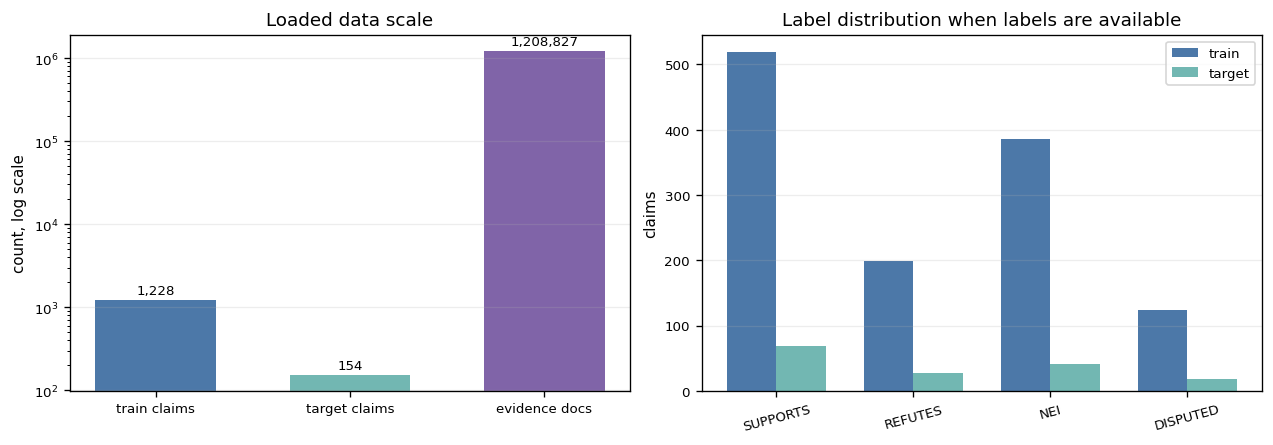

In [20]:
plot_dataset_overview(train_claims, target_claims, evidence)


# 2.Model Implementation


## Sparse Candidate Gates


In [21]:
def word_terms(text):
    toks = [t.lower() for t in TOKEN_RE.findall(text)]
    toks = [t for t in toks if len(t) > 1 and t not in STOPWORDS]
    return toks + [toks[i] + '_' + toks[i + 1] for i in range(len(toks) - 1)]

def structured_terms(text):
    toks = TOKEN_RE.findall(text)
    years = [t for t in toks if re.fullmatch(r'(?:1[5-9]|20)\d\d', t)]
    nums = [t for t in toks if re.search(r'\d', t)]
    caps = [t.lower() for t in toks if len(t) > 2 and t[0].isupper()]
    neg = [t.lower() for t in toks if t.lower() in NEG_WORDS]
    return ['Y_' + x for x in years] + ['N_' + x for x in nums] + ['E_' + x for x in caps] + ['NEG_' + x for x in neg]

def claim_feature(text):
    wt = word_terms(text)
    lower = text.lower()
    return {
        'word_set': set(wt),
        'nums': set(re.findall(r'\d+', text)),
        'neg_flag': any(w in lower for w in NEG_WORDS),
        'length': len(text),
    }

def build_claim_features(claims):
    return {cid: claim_feature(claim['claim_text']) for cid, claim in claims.items()}

train_claim_features = build_claim_features(train_claims)
target_claim_features = build_claim_features(target_claims)
EMPTY_POOL_ENTRY = (np.empty(0, dtype=np.int32), np.empty(0, dtype=np.float32))

@lru_cache(maxsize=20000)
def cached_word_terms_for_eid(eid):
    return tuple(word_terms(evidence.get(eid, '')))

def bm25_transform_counts_inplace(x_counts, k1=1.5, b=0.75):
    x = x_counts.tocsr(copy=False)
    if x.dtype != np.float32:
        x.data = x.data.astype(np.float32, copy=False)
    n_docs, n_terms = x.shape
    df = np.bincount(x.indices, minlength=n_terms).astype(np.float32, copy=False)
    idf = np.log((n_docs - df + 0.5) / (df + 0.5) + 1.0).astype(np.float32, copy=False)
    doc_len = np.asarray(x.sum(axis=1)).ravel().astype(np.float32, copy=False)
    doc_len = np.maximum(doc_len, 1.0)
    avgdl = float(doc_len.mean()) if len(doc_len) else 1.0
    row_nnz = np.diff(x.indptr)
    row_ids = np.repeat(np.arange(n_docs, dtype=np.int32), row_nnz)
    denom = x.data + k1 * (1.0 - b + b * doc_len[row_ids] / avgdl)
    x.data *= (k1 + 1.0)
    x.data /= denom
    x.data *= idf[x.indices]
    return x

def topk_arrays_from_scores(scores, evidence_id_array, top_k):
    if scores.size == 0:
        return EMPTY_POOL_ENTRY
    k = min(top_k, scores.size)
    if k <= 0:
        return EMPTY_POOL_ENTRY
    idx = np.argpartition(scores, -k)[-k:]
    idx = idx[np.lexsort((evidence_id_array[idx], -scores[idx]))]
    positive = scores[idx] > 0.0
    if not np.any(positive):
        return EMPTY_POOL_ENTRY
    idx = idx[positive].astype(np.int32, copy=False)
    vals = scores[idx].astype(np.float32, copy=True)
    return idx, vals

def score_matrix_topk(claim_ids, claim_matrix, evidence_matrix_bm25, evidence_ids, top_k, batch_size, label):
    start = time.perf_counter()
    out = {}
    ev_t = evidence_matrix_bm25.T.tocsr()
    evidence_id_array = np.asarray(evidence_ids, dtype=object)
    total_batches = max(1, math.ceil(len(claim_ids) / batch_size))
    progress_every = max(1, total_batches // 10)
    for batch_no, start_idx in enumerate(range(0, len(claim_ids), batch_size), start=1):
        end_idx = min(start_idx + batch_size, len(claim_ids))
        batch_scores = (claim_matrix[start_idx:end_idx] @ ev_t).toarray().astype(np.float32, copy=False)
        for local_idx, cid in enumerate(claim_ids[start_idx:end_idx]):
            out[cid] = topk_arrays_from_scores(batch_scores[local_idx], evidence_id_array, top_k)
        if batch_no % progress_every == 0 or end_idx == len(claim_ids):
            print(label, 'batch', end_idx, '/', len(claim_ids), 'elapsed', round(time.perf_counter() - start, 1), 's')
    del ev_t
    print(label, 'finished in', round(time.perf_counter() - start, 1), 's')
    return out

def expand_claim_texts_with_prf(claims, base_pool, evidence_ids, feedback_k=10, max_terms=12):
    expanded = []
    for cid, claim in claims.items():
        counts = Counter()
        doc_idxs, _ = base_pool.get(cid, EMPTY_POOL_ENTRY)
        for doc_idx in doc_idxs[:feedback_k]:
            counts.update(cached_word_terms_for_eid(evidence_ids[int(doc_idx)]))
        original = set(word_terms(claim['claim_text']))
        terms = [t.replace('_', ' ') for t, _ in counts.most_common(max_terms * 3) if t not in original and t.isascii()][:max_terms]
        expanded.append(claim['claim_text'] + ' ' + ' '.join(terms))
    return expanded

def rrf_fuse(claims, sources, weights, evidence_ids, top_k, rrf_k=500.0):
    fused = {}
    for cid in claims:
        scores = defaultdict(float)
        source_ranks = defaultdict(dict)
        for name, pool in sources.items():
            w = weights.get(name, 0.0)
            if w <= 0.0:
                continue
            doc_idxs, _ = pool.get(cid, EMPTY_POOL_ENTRY)
            limit = min(len(doc_idxs), top_k)
            for pos in range(limit):
                doc_idx = int(doc_idxs[pos])
                rank = pos + 1
                scores[doc_idx] += w / (rrf_k + rank)
                source_ranks[doc_idx][name + '_rank'] = rank
        best = sorted(scores.items(), key=lambda item: (-item[1], evidence_ids[item[0]]))[:top_k]
        rows = []
        for rank, (doc_idx, score) in enumerate(best, 1):
            rows.append({
                'evidence_id': evidence_ids[doc_idx],
                'score': float(score),
                'rank': rank,
                'source': 'sklearn_sparse_rrf_char_heavy',
                **source_ranks.get(doc_idx, {}),
            })
        fused[cid] = rows
    return fused

def build_candidate_evidence_features(*pools):
    needed = set()
    for pool in pools:
        for rows in pool.values():
            for row in rows[:CANDIDATE_TOP_K]:
                eid = row['evidence_id']
                if eid in evidence:
                    needed.add(eid)
    feats = {}
    for eid in needed:
        text = evidence[eid]
        lower = text.lower()
        feats[eid] = {
            'word_set': set(word_terms(text)),
            'nums': set(re.findall(r'\d+', text)),
            'neg_flag': any(w in lower for w in NEG_WORDS),
            'length': len(text),
        }
    print('candidate evidence feature cache', len(feats))
    return feats

evidence_ids = list(evidence)
evidence_texts = [evidence[eid] for eid in evidence_ids]
train_claim_ids = list(train_claims)
target_claim_ids = list(target_claims)
train_claim_texts = [train_claims[cid]['claim_text'] for cid in train_claim_ids]
target_claim_texts = [target_claims[cid]['claim_text'] for cid in target_claim_ids]

WORD_MAX_FEATURES = 200000
CHAR_MAX_FEATURES = 160000
CHAR_MIN_DF = 2
CHAR_MAX_DF = 0.25
MATRIX_BATCH_SIZE = 8

print('building word BM25 matrix')
word_vectorizer = CountVectorizer(analyzer=word_terms, max_features=WORD_MAX_FEATURES, dtype=np.float32)
t0 = time.perf_counter()
x_ev_word_bm25 = word_vectorizer.fit_transform(evidence_texts)
x_ev_word_bm25 = bm25_transform_counts_inplace(x_ev_word_bm25)
x_train_word = word_vectorizer.transform(train_claim_texts)
x_target_word = word_vectorizer.transform(target_claim_texts)
print('word matrix', x_ev_word_bm25.shape, 'nnz', x_ev_word_bm25.nnz, 'time', round(time.perf_counter() - t0, 1))
train_bm25 = score_matrix_topk(train_claim_ids, x_train_word, x_ev_word_bm25, evidence_ids, CANDIDATE_TOP_K, MATRIX_BATCH_SIZE, 'bm25 train')
target_bm25 = score_matrix_topk(target_claim_ids, x_target_word, x_ev_word_bm25, evidence_ids, CANDIDATE_TOP_K, MATRIX_BATCH_SIZE, 'bm25 target')
train_prf_texts = expand_claim_texts_with_prf(train_claims, train_bm25, evidence_ids)
target_prf_texts = expand_claim_texts_with_prf(target_claims, target_bm25, evidence_ids)
x_train_prf = word_vectorizer.transform(train_prf_texts)
x_target_prf = word_vectorizer.transform(target_prf_texts)
train_prf = score_matrix_topk(train_claim_ids, x_train_prf, x_ev_word_bm25, evidence_ids, CANDIDATE_TOP_K, MATRIX_BATCH_SIZE, 'prf train')
target_prf = score_matrix_topk(target_claim_ids, x_target_prf, x_ev_word_bm25, evidence_ids, CANDIDATE_TOP_K, MATRIX_BATCH_SIZE, 'prf target')
del x_ev_word_bm25, x_train_word, x_target_word, x_train_prf, x_target_prf, word_vectorizer, train_prf_texts, target_prf_texts
gc.collect()

print('building char BM25 matrix')
char_vectorizer = CountVectorizer(analyzer='char_wb', ngram_range=(3, 5), lowercase=True, max_features=CHAR_MAX_FEATURES, min_df=CHAR_MIN_DF, max_df=CHAR_MAX_DF, dtype=np.float32)
t0 = time.perf_counter()
x_ev_char_bm25 = char_vectorizer.fit_transform(evidence_texts)
x_ev_char_bm25 = bm25_transform_counts_inplace(x_ev_char_bm25)
x_train_char = char_vectorizer.transform(train_claim_texts)
x_target_char = char_vectorizer.transform(target_claim_texts)
print('char matrix', x_ev_char_bm25.shape, 'nnz', x_ev_char_bm25.nnz, 'time', round(time.perf_counter() - t0, 1))
train_char = score_matrix_topk(train_claim_ids, x_train_char, x_ev_char_bm25, evidence_ids, CANDIDATE_TOP_K, MATRIX_BATCH_SIZE, 'char train')
target_char = score_matrix_topk(target_claim_ids, x_target_char, x_ev_char_bm25, evidence_ids, CANDIDATE_TOP_K, MATRIX_BATCH_SIZE, 'char target')
del x_ev_char_bm25, x_train_char, x_target_char, char_vectorizer
gc.collect()

print('building structured BM25 matrix')
structured_evidence_texts = [' '.join(structured_terms(text)) for text in evidence_texts]
structured_train_texts = [' '.join(structured_terms(text)) for text in train_claim_texts]
structured_target_texts = [' '.join(structured_terms(text)) for text in target_claim_texts]
structured_vectorizer = CountVectorizer(token_pattern=r'(?u)\b\S+\b', dtype=np.float32)
t0 = time.perf_counter()
x_ev_struct_bm25 = structured_vectorizer.fit_transform(structured_evidence_texts)
x_ev_struct_bm25 = bm25_transform_counts_inplace(x_ev_struct_bm25)
x_train_struct = structured_vectorizer.transform(structured_train_texts)
x_target_struct = structured_vectorizer.transform(structured_target_texts)
print('structured matrix', x_ev_struct_bm25.shape, 'nnz', x_ev_struct_bm25.nnz, 'time', round(time.perf_counter() - t0, 1))
train_struct = score_matrix_topk(train_claim_ids, x_train_struct, x_ev_struct_bm25, evidence_ids, CANDIDATE_TOP_K, MATRIX_BATCH_SIZE, 'structured train')
target_struct = score_matrix_topk(target_claim_ids, x_target_struct, x_ev_struct_bm25, evidence_ids, CANDIDATE_TOP_K, MATRIX_BATCH_SIZE, 'structured target')
del x_ev_struct_bm25, x_train_struct, x_target_struct, structured_vectorizer, structured_evidence_texts, structured_train_texts, structured_target_texts
gc.collect()

weights = {'bm25': 0.75, 'char': 2.0, 'structured': 0.25, 'prf': 0.5}
train_candidates = rrf_fuse(train_claims, {'bm25': train_bm25, 'char': train_char, 'structured': train_struct, 'prf': train_prf}, weights, evidence_ids, CANDIDATE_TOP_K, SPARSE_RRF_K)
target_candidates = rrf_fuse(target_claims, {'bm25': target_bm25, 'char': target_char, 'structured': target_struct, 'prf': target_prf}, weights, evidence_ids, CANDIDATE_TOP_K, SPARSE_RRF_K)
del train_bm25, target_bm25, train_char, target_char, train_struct, target_struct, train_prf, target_prf
gc.collect()
evidence_features = build_candidate_evidence_features(train_candidates, target_candidates)
save_artifact(OUTPUT_DIR / 'train_sparse_fusion_top500.json', train_candidates)
save_artifact(OUTPUT_DIR / 'target_sparse_fusion_top500.json', target_candidates)
save_artifact(OUTPUT_DIR / 'candidate_metrics.json', {'target_top500': retrieval_metrics(target_claims, target_candidates, min(500, CANDIDATE_TOP_K)), 'weights': weights})
print('candidate weights', weights)
print('candidate metrics', retrieval_metrics(target_claims, target_candidates, min(500, CANDIDATE_TOP_K)))


building word BM25 matrix
word matrix (1208827, 200000) nnz 15921368 time 38.3
bm25 train batch 120 / 1228 elapsed 3.4 s
bm25 train batch 240 / 1228 elapsed 6.6 s
bm25 train batch 360 / 1228 elapsed 9.9 s
bm25 train batch 480 / 1228 elapsed 13.4 s
bm25 train batch 600 / 1228 elapsed 16.6 s
bm25 train batch 720 / 1228 elapsed 19.8 s
bm25 train batch 840 / 1228 elapsed 23.1 s
bm25 train batch 960 / 1228 elapsed 26.3 s
bm25 train batch 1080 / 1228 elapsed 29.9 s
bm25 train batch 1200 / 1228 elapsed 33.2 s
bm25 train batch 1228 / 1228 elapsed 34.0 s
bm25 train finished in 34.0 s
bm25 target batch 16 / 154 elapsed 0.7 s
bm25 target batch 32 / 154 elapsed 1.1 s
bm25 target batch 48 / 154 elapsed 1.6 s
bm25 target batch 64 / 154 elapsed 2.0 s
bm25 target batch 80 / 154 elapsed 2.4 s
bm25 target batch 96 / 154 elapsed 2.9 s
bm25 target batch 112 / 154 elapsed 3.4 s
bm25 target batch 128 / 154 elapsed 3.8 s
bm25 target batch 144 / 154 elapsed 4.3 s
bm25 target batch 154 / 154 elapsed 4.6 s
bm25

## Candidate Diagnostics


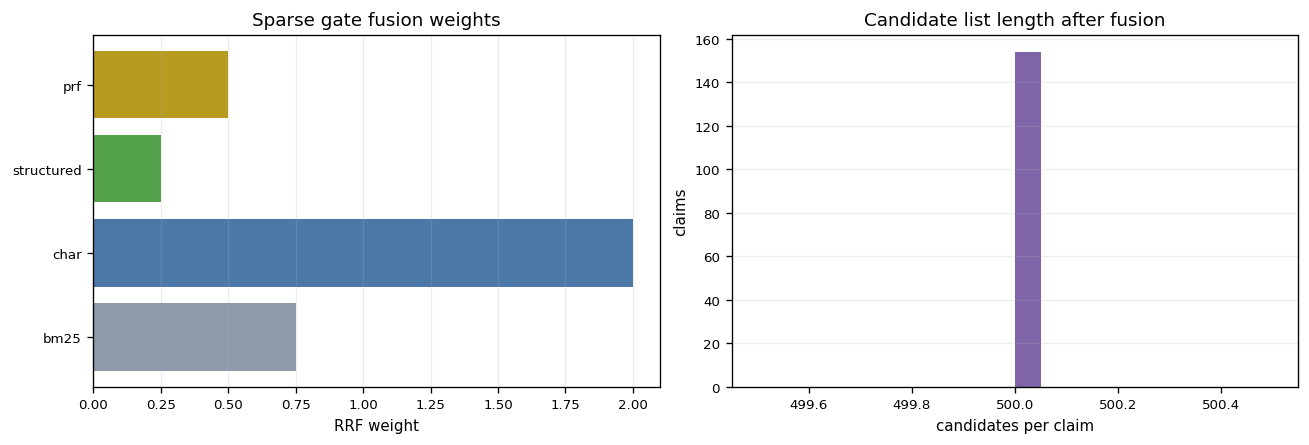

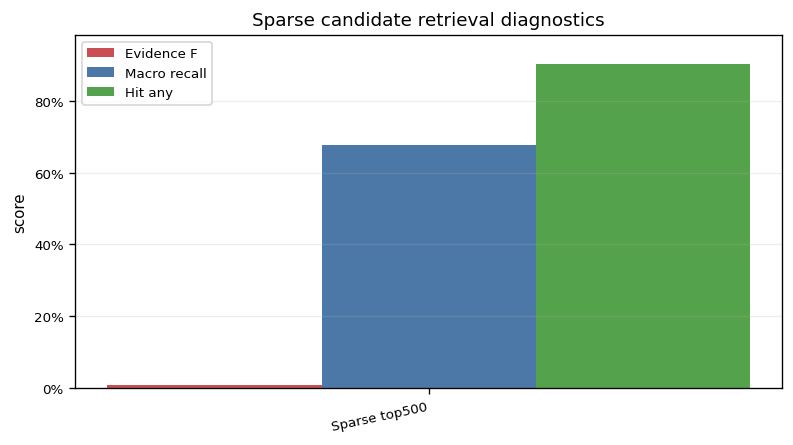

In [22]:
plot_sparse_candidate_diagnostics(weights, target_claims, target_candidates, CANDIDATE_TOP_K)


## Top64: MiniLM Embedding Inner Product + Hand Features


In [23]:
def mean_pool(outputs, attention_mask):
    token_embeddings=outputs.last_hidden_state
    mask=attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings*mask).sum(1)/torch.clamp(mask.sum(1), min=1e-9)

@torch.inference_mode()
def encode_texts(texts, tokenizer, model, batch_size=BATCH_EMBED):
    vecs=[]; model.eval()
    for st in range(0,len(texts),batch_size):
        batch=tokenizer(texts[st:st+batch_size], padding=True, truncation=True, max_length=MAX_EMBED_LENGTH, return_tensors='pt')
        batch={k:v.to(DEVICE) for k,v in batch.items()}
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(DEVICE.type=='cuda')):
            out=model(**batch)
            emb=mean_pool(out, batch['attention_mask'])
        vecs.append(F.normalize(emb.float(), dim=1).cpu())
    return torch.cat(vecs,0) if vecs else torch.empty((0,384))

def candidate_union(*pools):
    ids=[]; seen=set()
    for pool in pools:
        for rows in pool.values():
            for row in rows[:CANDIDATE_TOP_K]:
                eid=row['evidence_id']
                if eid not in seen and eid in evidence: seen.add(eid); ids.append(eid)
    return ids

embed_tokenizer=AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
embed_model=AutoModel.from_pretrained(EMBEDDING_MODEL_NAME).to(DEVICE)
all_eids=candidate_union(train_candidates, target_candidates)
print('embedding evidence subset', len(all_eids))
eid_to_idx={eid:i for i,eid in enumerate(all_eids)}
evidence_emb=encode_texts([evidence[eid] for eid in all_eids], embed_tokenizer, embed_model).contiguous()
train_claim_ids=list(train_claims); target_claim_ids=list(target_claims)
train_claim_emb=encode_texts([train_claims[cid]['claim_text'] for cid in train_claim_ids], embed_tokenizer, embed_model).contiguous()
target_claim_emb=encode_texts([target_claims[cid]['claim_text'] for cid in target_claim_ids], embed_tokenizer, embed_model).contiguous()

def add_embedding_scores(claims, claim_ids, claim_emb, pool):
    out={}
    for qi,cid in enumerate(claim_ids):
        base_rows=[]; idxs=[]
        for row in pool.get(cid, [])[:CANDIDATE_TOP_K]:
            eid=row['evidence_id']
            idx=eid_to_idx.get(eid)
            if idx is not None:
                base_rows.append(row); idxs.append(idx)
        if not idxs:
            out[cid]=[]; continue
        idx_tensor=torch.as_tensor(idxs, dtype=torch.long)
        scores=(evidence_emb[idx_tensor] @ claim_emb[qi]).numpy()
        rows=[{**row, 'embedding_score': float(score)} for row,score in zip(base_rows, scores)]
        rows.sort(key=lambda r:(-r['embedding_score'], r.get('rank',999999), r['evidence_id']))
        for i,r in enumerate(rows,1): r['embedding_rank']=i
        out[cid]=rows
    return out

train_embed_ranked=add_embedding_scores(train_claims, train_claim_ids, train_claim_emb, train_candidates)
target_embed_ranked=add_embedding_scores(target_claims, target_claim_ids, target_claim_emb, target_candidates)

def overlap_features_from_cache(claim_feat, ev_feat, sparse_rank, emb_score):
    ct=claim_feat['word_set']; et=ev_feat['word_set']; inter=len(ct & et)
    return [
        1.0/max(sparse_rank,1), emb_score, inter/max(len(ct),1), inter/max(len(et),1),
        len(claim_feat['nums'] & ev_feat['nums']), abs(claim_feat['length']-ev_feat['length'])/1000.0,
        float(claim_feat['neg_flag'] == ev_feat['neg_flag'])
    ]

def build_feature_rows(claims, claim_features_by_id, ranked, max_neg=80):
    X=[]; y=[]
    rng=random.Random(SEED)
    for cid, claim in claims.items():
        gold=set(claim.get('evidences', [])); pos=[]; neg=[]; cf=claim_features_by_id[cid]
        for row in ranked.get(cid, [])[:CANDIDATE_TOP_K]:
            ef=evidence_features.get(row['evidence_id'])
            if ef is None: continue
            feat=overlap_features_from_cache(cf, ef, row.get('rank',999), row.get('embedding_score',0.0))
            if row['evidence_id'] in gold: pos.append(feat)
            else: neg.append(feat)
        if len(neg)>max_neg: neg=neg[:max_neg//2]+rng.sample(neg[max_neg//2:], min(len(neg)-max_neg//2, max_neg-max_neg//2))
        X.extend(pos); y.extend([1]*len(pos)); X.extend(neg); y.extend([0]*len(neg))
    return np.asarray(X,dtype=np.float32), np.asarray(y,dtype=np.int64)

X,y=build_feature_rows(train_claims, train_claim_features, train_embed_ranked)
hand_model=HistGradientBoostingClassifier(max_iter=120, learning_rate=0.06, random_state=SEED, class_weight='balanced')
hand_model.fit(X,y)

def score_embedding_hand(claims, claim_features_by_id, ranked, top_k=TOP64_K):
    out={}
    for cid, claim in claims.items():
        feats=[]; rows=[]; cf=claim_features_by_id[cid]
        for row in ranked.get(cid, [])[:CANDIDATE_TOP_K]:
            ef=evidence_features.get(row['evidence_id'])
            if ef is None: continue
            feats.append(overlap_features_from_cache(cf, ef, row.get('rank',999), row.get('embedding_score',0.0)))
            rows.append(row)
        if feats:
            probs=hand_model.predict_proba(np.asarray(feats,dtype=np.float32))[:,1]
            emb=np.asarray([r.get('embedding_score',0.0) for r in rows]); emb=(emb-emb.min())/(emb.max()-emb.min()+1e-9)
            final=0.65*emb+0.35*probs
            for r,p,s in zip(rows, probs, final): r['hand_score']=float(p); r['top64_score']=float(s); r['source']='embedding_plus_shallow'
            rows.sort(key=lambda r:(-r['top64_score'], r['embedding_rank'], r['evidence_id']))
        for i,r in enumerate(rows[:top_k],1): r['rank']=i
        out[cid]=rows[:top_k]
    return out

train_top64=score_embedding_hand(train_claims, train_claim_features, train_embed_ranked)
target_top64=score_embedding_hand(target_claims, target_claim_features, target_embed_ranked)
save_artifact(OUTPUT_DIR/'train_top64_embedding_hand.json', train_top64)
save_artifact(OUTPUT_DIR/'target_top64_embedding_hand.json', target_top64)
save_artifact(OUTPUT_DIR/'top64_metrics.json', retrieval_metrics(target_claims, target_top64, min(64,TOP64_K)))
print('top64 metrics', retrieval_metrics(target_claims, target_top64, min(64,TOP64_K)))

del embed_model
if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding evidence subset 195525
top64 metrics {'evidence_f@64': 0.05173643362054943, 'macro_recall@64': 0.5783549783549783, 'hit_any@64': 0.8636363636363636}


0

## Top64 Diagnostics

The first diagnostic compares retrieval quality before and after the top64 reranker on labelled targets. The second diagnostic is a score sanity check, not a performance metric: it shows the distribution of the three values stored for the retained top64 candidates.

- `embedding_score` is the MiniLM claim--evidence inner-product score.
- `hand_score` is the shallow factual matching model's positive probability, using overlap, numeric, length, negation, and rank features.
- `top64_score` is the final within-claim normalized fusion score used to sort the top64 pool.

The expected pattern is that the fused `top64_score` has a higher mean than either individual component and a smaller standard deviation than the noisier hand-feature score. In other words, the fusion step should raise the average retained-candidate quality while reducing score variance. Retrieval effectiveness should still be read from the stage recall/F-score plot, not from this component-distribution boxplot.


In [ ]:
plot_retrieval_stage('Top64 reranking diagnostics', target_claims, [('Sparse top500', target_candidates, min(500, CANDIDATE_TOP_K)), ('Embedding + shallow top64', target_top64, min(64, TOP64_K))])
plot_score_distribution('Top64 fusion raises mean and stabilizes retained scores', target_top64, ['embedding_score', 'hand_score', 'top64_score'])


## Top3: CE + Embedding Fusion


In [25]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, rows): self.rows=rows
    def __len__(self): return len(self.rows)
    def __getitem__(self,i): return self.rows[i]

def truncate_words(text, budget=80):
    return ' '.join(text.split()[:budget])

def collate_ce(batch):
    enc=ce_tokenizer([b['claim_text'] for b in batch], [b['evidence_text'] for b in batch], padding=True, truncation=True, max_length=MAX_CE_LENGTH, return_tensors='pt')
    return enc, batch

TOP3_CE_PREFILTER_K = min(256, CANDIDATE_TOP_K)
TOP3_FUSION_WEIGHTS = {
    'ce_score': 0.25,
    'embedding_score': 0.25,
    'embedding_rank': 0.25,
    'source_rank': 0.25,
}

@torch.inference_mode()
def ce_score_top3_prefilter(claims, ranked, prefilter_k=TOP3_CE_PREFILTER_K):
    pairs=[]
    for cid, claim in claims.items():
        rows=list(ranked.get(cid, [])[:CANDIDATE_TOP_K])
        rows.sort(key=lambda r:(min(int(r.get('rank', 10**9)), int(r.get('embedding_rank', 10**9))), int(r.get('rank', 10**9)), int(r.get('embedding_rank', 10**9)), r['evidence_id']))
        for row in rows[:prefilter_k]:
            pairs.append({
                'claim_id':cid,
                'evidence_id':row['evidence_id'],
                'claim_text':claim['claim_text'],
                'evidence_text':truncate_words(evidence.get(row['evidence_id'],''), 90),
            })
    loader=torch.utils.data.DataLoader(PairDataset(pairs), batch_size=BATCH_CE, shuffle=False, collate_fn=collate_ce)
    out=defaultdict(dict); ce_model.eval()
    done=0
    for enc,batch_rows in loader:
        enc={k:v.to(DEVICE) for k,v in enc.items()}
        logits=ce_model(**enc).logits.detach().float().cpu().numpy()
        scores=logits[:,0] if logits.ndim==2 else logits
        for row,score in zip(batch_rows, scores):
            out[row['claim_id']][row['evidence_id']]=float(score)
        done += len(batch_rows)
        if done % (BATCH_CE*20) == 0 or done == len(pairs):
            print('top3 CE scored', done, '/', len(pairs))
    return out

def minmax_array(vals):
    vals=np.asarray(vals,dtype=np.float32)
    if len(vals)==0: return vals
    lo=float(vals.min()); hi=float(vals.max())
    return np.zeros_like(vals,dtype=np.float32) if hi-lo<=1e-12 else ((vals-lo)/(hi-lo)).astype(np.float32)

def top500_ce_embedding_source_fusion(claims, ranked, ce_by_claim, weights=TOP3_FUSION_WEIGHTS):
    out={}
    missing_rank=CANDIDATE_TOP_K+1
    for cid in claims:
        rows=[dict(r) for r in ranked.get(cid, [])[:CANDIDATE_TOP_K]]
        if not rows:
            out[cid]=[]; continue
        emb_vals=minmax_array([r.get('embedding_score',0.0) for r in rows])
        ce_map=ce_by_claim.get(cid,{})
        ce_items=sorted(ce_map.items(), key=lambda item:(-item[1], item[0]))
        ce_rank={eid:i for i,(eid,_) in enumerate(ce_items,1)}
        ce_norm={}
        if ce_items:
            norm_vals=minmax_array([score for _,score in ce_items])
            ce_norm={eid:float(v) for (eid,_),v in zip(ce_items,norm_vals)}
        for i,r in enumerate(rows):
            eid=r['evidence_id']
            src_rank=max(1,int(r.get('rank', missing_rank)))
            emb_rank=max(1,int(r.get('embedding_rank', missing_rank)))
            cr=ce_rank.get(eid)
            score=(
                weights.get('ce_score',0.0)*ce_norm.get(eid,0.0)
                + weights.get('embedding_score',0.0)*float(emb_vals[i])
                + weights.get('embedding_rank',0.0)*(1.0/(60.0+float(emb_rank)))
                + weights.get('source_rank',0.0)*(1.0/(60.0+float(src_rank)))
            )
            r['ce_score']=float(ce_map.get(eid,0.0))
            r['ce_rank']=None if cr is None else int(cr)
            r['fusion_score']=float(score)
            r['source']='top500_ce_embedding_source_fusion'
        rows.sort(key=lambda r:(-r['fusion_score'], r['ce_rank'] if r['ce_rank'] is not None else 10**9, r.get('embedding_rank',10**9), r.get('rank',10**9), r['evidence_id']))
        for rank,r in enumerate(rows,1): r['rank']=rank
        out[cid]=rows
    return out

ce_tokenizer=AutoTokenizer.from_pretrained(CE_MODEL_NAME)
ce_model=AutoModelForSequenceClassification.from_pretrained(CE_MODEL_NAME).to(DEVICE)
target_ce_scores=ce_score_top3_prefilter(target_claims, target_embed_ranked, TOP3_CE_PREFILTER_K)
target_top3_ranked=top500_ce_embedding_source_fusion(target_claims, target_embed_ranked, target_ce_scores, TOP3_FUSION_WEIGHTS)
save_artifact(OUTPUT_DIR/'target_top3_ce_embedding_source_fusion.json', target_top3_ranked)
save_artifact(OUTPUT_DIR/'top3_metrics.json', {
    'target_top3': retrieval_metrics(target_claims, target_top3_ranked, FINAL_EVIDENCE_TOP_K),
    'weights': TOP3_FUSION_WEIGHTS,
    'ce_prefilter_k': TOP3_CE_PREFILTER_K,
})
print('top3 weights', TOP3_FUSION_WEIGHTS, 'ce_prefilter_k', TOP3_CE_PREFILTER_K)
print('top3 metrics', retrieval_metrics(target_claims, target_top3_ranked, FINAL_EVIDENCE_TOP_K))

del ce_model, ce_tokenizer, target_ce_scores
if torch.cuda.is_available(): torch.cuda.empty_cache()
gc.collect()


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

top3 CE scored 1280 / 39424
top3 CE scored 2560 / 39424
top3 CE scored 3840 / 39424
top3 CE scored 5120 / 39424
top3 CE scored 6400 / 39424
top3 CE scored 7680 / 39424
top3 CE scored 8960 / 39424
top3 CE scored 10240 / 39424
top3 CE scored 11520 / 39424
top3 CE scored 12800 / 39424
top3 CE scored 14080 / 39424
top3 CE scored 15360 / 39424
top3 CE scored 16640 / 39424
top3 CE scored 17920 / 39424
top3 CE scored 19200 / 39424
top3 CE scored 20480 / 39424
top3 CE scored 21760 / 39424
top3 CE scored 23040 / 39424
top3 CE scored 24320 / 39424
top3 CE scored 25600 / 39424
top3 CE scored 26880 / 39424
top3 CE scored 28160 / 39424
top3 CE scored 29440 / 39424
top3 CE scored 30720 / 39424
top3 CE scored 32000 / 39424
top3 CE scored 33280 / 39424
top3 CE scored 34560 / 39424
top3 CE scored 35840 / 39424
top3 CE scored 37120 / 39424
top3 CE scored 38400 / 39424
top3 CE scored 39424 / 39424
top3 weights {'ce_score': 0.25, 'embedding_score': 0.25, 'embedding_rank': 0.25, 'source_rank': 0.25} ce_pre

2928

## Top3 Diagnostics


These diagnostics intentionally avoid plotting raw fusion weights or raw score distributions. The active Top3 fusion uses four non-zero signals: cross-encoder confidence, embedding similarity, embedding rank, and source rank. `ce_rank` is disabled and omitted because its weight is zero. Raw CE logits and normalized fusion scores are on different scales, so a boxplot of those values is not a meaningful comparison.

The bar chart shows the operating points used by the submitted system. The recall-vs-K curve shows why the pipeline keeps a broad top500 candidate set, compresses it to a top64 context pool, and only then selects the top3 submitted evidence: recall drops as K gets smaller, but the expensive scoring budget also drops sharply.


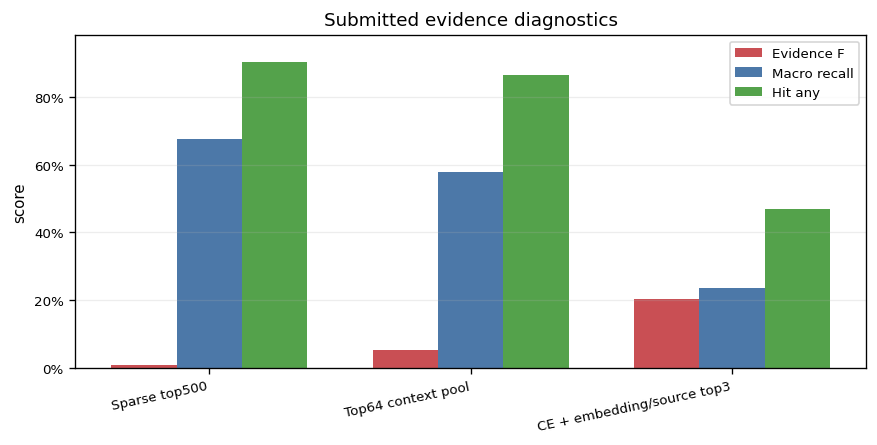

In [26]:
plot_retrieval_stage('Submitted evidence diagnostics', target_claims, [('Sparse top500', target_candidates, min(500, CANDIDATE_TOP_K)), ('Top64 context pool', target_top64, min(64, TOP64_K)), ('CE + embedding/source top3', target_top3_ranked, FINAL_EVIDENCE_TOP_K)])
plot_recall_vs_k_curves('Recall-vs-K across retrieval stages', target_claims, [
    ('Sparse candidate pool', target_candidates, [1, 3, 5, 10, 20, 32, 64, 100, 200, min(500, CANDIDATE_TOP_K)]),
    ('Top64 reranked pool', target_top64, [1, 3, 5, 10, 20, 32, min(64, TOP64_K)]),
    ('Submitted top3 ranking', target_top3_ranked, [1, 2, FINAL_EVIDENCE_TOP_K]),
])


## Classifier: Enhanced Context20 TF-IDF Logistic Regression


In [27]:
CLASSIFIER_CONFIG = {
    'context_mode': 'enhanced',
    'context_k': 20,
    'top_budget': 120,
    'tail_budget': 50,
    'max_features': 60000,
    'C': 0.125,
    'class_weight': 'balanced',
    'ngram_range': (1, 2),
    'stop_words': True,
    'min_df': 1,
    'sublinear_tf': False,
    'solver': 'liblinear',
}
NEG_WORDS = {'no', 'not', 'never', 'without', 'none', 'neither', 'nor'}
NUM_RE = re.compile(r'\b\d+(?:\.\d+)?\b')

def classifier_word_set(text):
    return {w.lower() for w in TOKEN_RE.findall(text) if len(w) > 2}

def classifier_num_set(text):
    return set(NUM_RE.findall(text))

def classifier_neg_flag(text):
    return bool({w.lower() for w in TOKEN_RE.findall(text)} & NEG_WORDS)

def classifier_cue_tokens(claim_text, ev_text):
    cw = classifier_word_set(claim_text)
    ew = classifier_word_set(ev_text)
    overlap = len(cw & ew) / max(len(cw), 1)
    cnums = classifier_num_set(claim_text)
    enums = classifier_num_set(ev_text)
    cues = []
    if overlap >= 0.45:
        cues.append('WORD_OVERLAP_HIGH')
    elif overlap >= 0.25:
        cues.append('WORD_OVERLAP_MED')
    elif overlap > 0:
        cues.append('WORD_OVERLAP_LOW')
    else:
        cues.append('WORD_OVERLAP_NONE')
    if cnums and enums:
        cues.append('NUMBER_MATCH' if cnums & enums else 'NUMBER_MISMATCH')
    elif cnums:
        cues.append('CLAIM_NUMBER_ONLY')
    cues.append('NEGATION_MATCH' if classifier_neg_flag(claim_text) == classifier_neg_flag(ev_text) else 'NEGATION_MISMATCH')
    return ' '.join(cues)

def classifier_rank_prefix(rank, mode):
    if mode in {'rank_aware', 'rank_weighted', 'enhanced'}:
        if rank <= 5:
            return 'TOP_EVIDENCE'
        if rank <= 20:
            return 'MID_EVIDENCE'
        return 'LOW_EVIDENCE'
    return 'EVIDENCE'

def classifier_text(claim, rows, config=CLASSIFIER_CONFIG):
    mode = config['context_mode']
    parts = [f"CLAIM: {claim['claim_text']}"]
    for i, row in enumerate(rows[:config['context_k']], 1):
        txt = evidence.get(row['evidence_id'], '')
        budget = config['top_budget'] if i <= 5 else config['tail_budget']
        if budget:
            txt = ' '.join(txt.split()[:budget])
        cues = (' ' + classifier_cue_tokens(claim['claim_text'], txt)) if mode == 'enhanced' else ''
        line = f"{classifier_rank_prefix(i, mode)}{cues}: {txt}"
        parts.append(line)
        if mode in {'top5_weighted', 'rank_weighted', 'enhanced'} and i <= 5:
            parts.append(line)
    return '\n'.join(parts)

def rows_for_classifier(claims, pool, config=CLASSIFIER_CONFIG, require_label=True):
    rows=[]
    for cid,claim in claims.items():
        if require_label and 'claim_label' not in claim:
            continue
        rows.append({
            'claim_id':cid,
            'text':classifier_text(claim, pool.get(cid, []), config),
            'label':claim.get('claim_label'),
        })
    return rows

def fit_predict_classifier(train_rows, target_rows, config=CLASSIFIER_CONFIG):
    vectorizer=TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        stop_words='english' if config['stop_words'] else None,
        ngram_range=config['ngram_range'],
        max_features=config['max_features'],
        min_df=config['min_df'],
        sublinear_tf=config['sublinear_tf'],
        dtype=np.float32,
    )
    X_train=vectorizer.fit_transform([r['text'] for r in train_rows])
    y_train_local=[r['label'] for r in train_rows]
    base_clf=LogisticRegression(C=config['C'], solver=config['solver'], max_iter=2000, class_weight=config['class_weight'], random_state=SEED)
    clf=OneVsRestClassifier(base_clf) if config['solver'] == 'liblinear' else base_clf
    clf.fit(X_train, y_train_local)
    X_target=vectorizer.transform([r['text'] for r in target_rows])
    preds=clf.predict(X_target).astype(str).tolist()
    return preds, vectorizer, clf

train_rows=rows_for_classifier(train_claims, train_top64, CLASSIFIER_CONFIG, True)
target_rows=rows_for_classifier(target_claims, target_top64, CLASSIFIER_CONFIG, False)
preds, vectorizer, clf = fit_predict_classifier(train_rows, target_rows, CLASSIFIER_CONFIG)
y_train=[r['label'] for r in train_rows]
labels_by_claim={r['claim_id']:p for r,p in zip(target_rows,preds)}
save_artifact(OUTPUT_DIR/'predicted_labels.json', labels_by_claim)

classifier_result={
    'method':'Enhanced Context20 TF-IDF One-vs-Rest Logistic Regression',
    'selection':'fixed_from_dev_context_format_sweep_C0p125',
    'selected_config':CLASSIFIER_CONFIG,
    'prediction_histogram':dict(Counter(preds)),
}
if has_labels(target_claims):
    y_true=[target_claims[r['claim_id']]['claim_label'] for r in target_rows]
    classifier_result.update({
        'accuracy':accuracy_score(y_true,preds),
        'macro_f1':f1_score(y_true,preds,labels=LABELS,average='macro',zero_division=0),
        'classification_report':classification_report(y_true,preds,labels=LABELS,zero_division=0),
        'confusion_matrix':confusion_matrix(y_true,preds,labels=LABELS).tolist(),
    })
save_artifact(OUTPUT_DIR/'classifier_metrics.json', classifier_result)
print(json.dumps(classifier_result, indent=2)[:3000])


{
  "method": "Enhanced Context20 TF-IDF One-vs-Rest Logistic Regression",
  "selection": "fixed_from_dev_context_format_sweep_C0p125",
  "selected_config": {
    "context_mode": "enhanced",
    "context_k": 20,
    "top_budget": 120,
    "tail_budget": 50,
    "max_features": 60000,
    "C": 0.125,
    "class_weight": "balanced",
    "ngram_range": [
      1,
      2
    ],
    "stop_words": true,
    "min_df": 1,
    "sublinear_tf": false,
    "solver": "liblinear"
  },
  "prediction_histogram": {
    "REFUTES": 40,
    "NOT_ENOUGH_INFO": 46,
    "SUPPORTS": 56,
    "DISPUTED": 12
  },
  "accuracy": 0.5194805194805194,
  "macro_f1": 0.4841408917592239,
  "classification_report": "                 precision    recall  f1-score   support\n\n       SUPPORTS       0.70      0.57      0.63        68\n        REFUTES       0.38      0.56      0.45        27\nNOT_ENOUGH_INFO       0.43      0.49      0.46        41\n       DISPUTED       0.50      0.33      0.40        18\n\n       accuracy

## Classifier Diagnostics

The classifier diagnostics report complementary views of the same predictions. The row-normalized confusion matrix controls for class support and shows per-gold-label recall patterns; the per-class precision/recall/F1 chart makes the classification report easier to inspect visually.


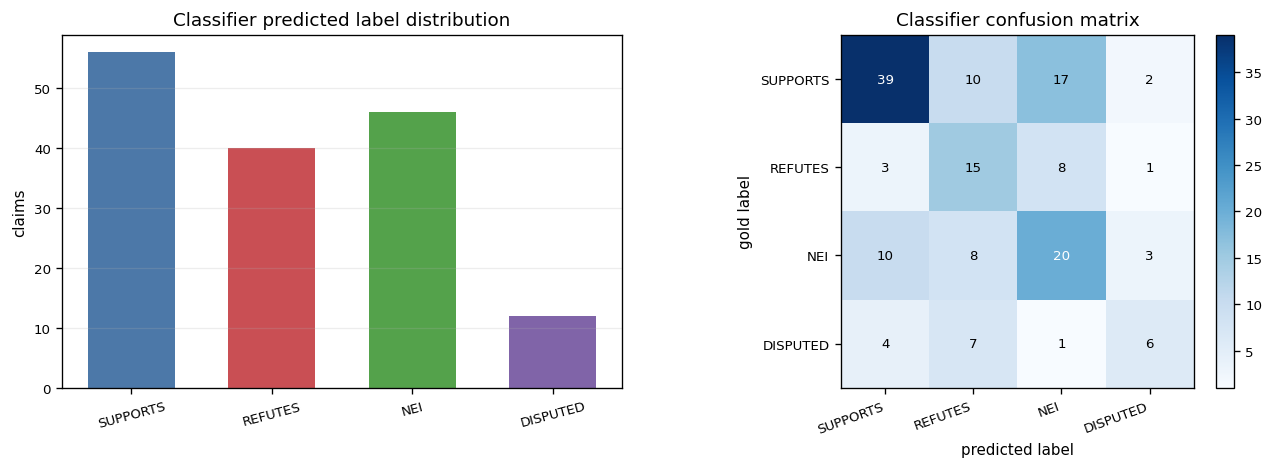

In [28]:
plot_classifier_diagnostics(classifier_result)


# 3.Testing and Evaluation


In [29]:
final_predictions={}
for cid in target_claims:
    final_predictions[cid]={'claim_label': labels_by_claim.get(cid, Counter(y_train).most_common(1)[0][0]), 'evidences':[r['evidence_id'] for r in target_top3_ranked.get(cid,[])[:FINAL_EVIDENCE_TOP_K]]}
save_artifact(OUTPUT_DIR/'final_predictions.json', final_predictions, force=True)

summary={'mode':'self-contained submission-resource generation','base_dir':str(BASE_DIR),'output_dir':str(OUTPUT_DIR),'candidate':retrieval_metrics(target_claims,target_candidates,min(500,CANDIDATE_TOP_K)),'top64':retrieval_metrics(target_claims,target_top64,min(64,TOP64_K)),'top3':retrieval_metrics(target_claims,target_top3_ranked,FINAL_EVIDENCE_TOP_K),'classifier':classifier_result,'label_counts':dict(Counter(p['claim_label'] for p in final_predictions.values())),'total_wall_seconds':time.perf_counter()-NOTEBOOK_START}
if has_labels(target_claims):
    y_true=[LABEL_TO_ID[target_claims[cid]['claim_label']] for cid in target_claims]
    y_pred=[LABEL_TO_ID[final_predictions[cid]['claim_label']] for cid in target_claims]
    ef=float(np.mean([evidence_f_score(target_claims[cid].get('evidences',[]), final_predictions[cid]['evidences']) for cid in target_claims]))
    acc=float(np.mean([a==b for a,b in zip(y_true,y_pred)]))
    summary['final_metrics']={'evidence_f':ef,'accuracy':acc,'harmonic':0.0 if ef+acc==0 else 2*ef*acc/(ef+acc),'top3_macro_recall':summary['top3'].get('macro_recall@3'),'classification_macro_f1':f1_score(y_true,y_pred,labels=list(range(len(LABELS))),average='macro',zero_division=0)}
    print('OFFICIAL COURSE METRICS')
    print(f"Evidence Retrieval F-score (F)    = {summary['final_metrics']['evidence_f']:.12f}")
    print(f"Claim Classification Accuracy (A) = {summary['final_metrics']['accuracy']:.12f}")
    print(f"Harmonic Mean of F and A          = {summary['final_metrics']['harmonic']:.12f}")
    print('DIAGNOSTIC METRICS')
    print(json.dumps(summary['final_metrics'], indent=2))
    print('CLASSIFICATION REPORT')
    print(classification_report(y_true,y_pred,target_names=LABELS,labels=list(range(len(LABELS))),zero_division=0))
    print('CONFUSION MATRIX')
    print(confusion_matrix(y_true,y_pred,labels=list(range(len(LABELS)))))
else:
    print('Target claims are unlabelled; evaluation skipped.')
save_artifact(OUTPUT_DIR/'run_summary.json', summary, force=True)
print('Wrote', OUTPUT_DIR/'final_predictions.json')
print('Wrote', OUTPUT_DIR/'run_summary.json')


OFFICIAL COURSE METRICS
Evidence Retrieval F-score (F)    = 0.202102659246
Claim Classification Accuracy (A) = 0.519480519481
Harmonic Mean of F and A          = 0.290994572791
DIAGNOSTIC METRICS
{
  "evidence_f": 0.2021026592455164,
  "accuracy": 0.5194805194805194,
  "harmonic": 0.29099457279093893,
  "top3_macro_recall": 0.23549783549783548,
  "classification_macro_f1": 0.4841408917592239
}
CLASSIFICATION REPORT
                 precision    recall  f1-score   support

       SUPPORTS       0.70      0.57      0.63        68
        REFUTES       0.38      0.56      0.45        27
NOT_ENOUGH_INFO       0.43      0.49      0.46        41
       DISPUTED       0.50      0.33      0.40        18

       accuracy                           0.52       154
      macro avg       0.50      0.49      0.48       154
   weighted avg       0.55      0.52      0.53       154

CONFUSION MATRIX
[[39 10 17  2]
 [ 3 15  8  1]
 [10  8 20  3]
 [ 4  7  1  6]]
Wrote /mnt/a/code/NLP/A3/data/outputs/self_g

## Final Visual Summary

These figures summarize only the selected pipeline output. They do not perform extra tuning or analysis: the first figure shows evidence-stage and final scores, and the second figure shows classifier behavior when labels are available.


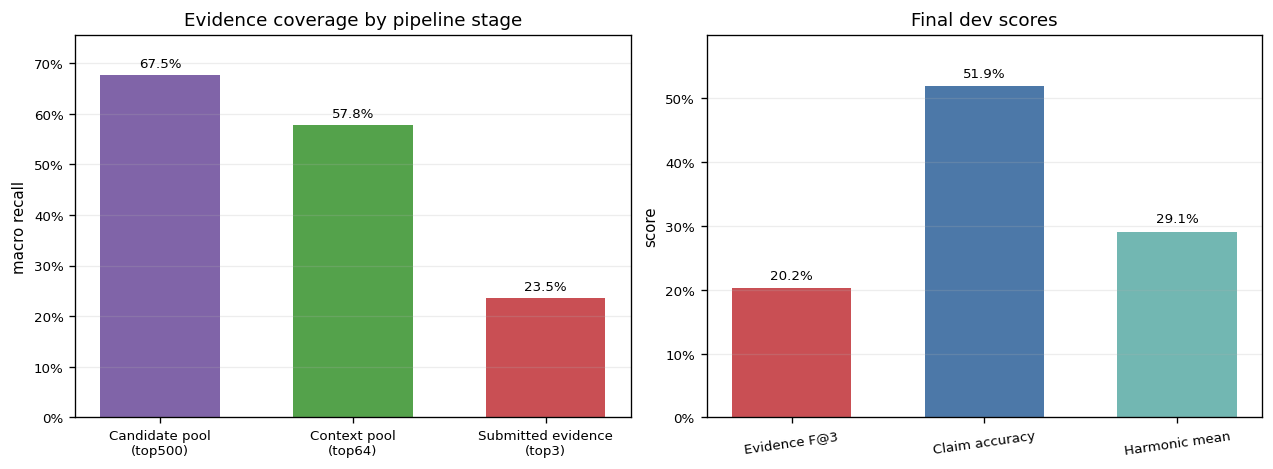

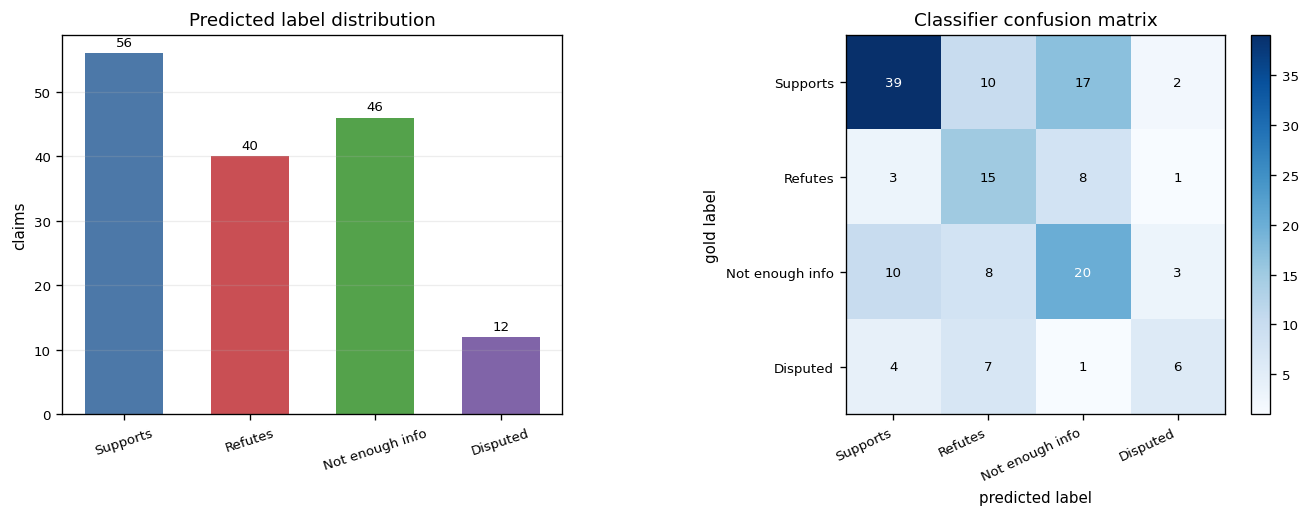

Total local runtime: 369.4 seconds


In [30]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def _metric(summary, section, name):
    value = summary.get(section, {}).get(name)
    return 0.0 if value is None else float(value)

def plot_final_visual_summary(summary, classifier_result):
    if not VISUALIZE:
        print('A3_VISUALIZE=0; final visualization skipped.')
        return
    plt.rcParams.update({
        'figure.dpi': 120,
        'axes.titlesize': 11,
        'axes.labelsize': 9,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
    })
    stage_names = ['Candidate pool\n(top500)', 'Context pool\n(top64)', 'Submitted evidence\n(top3)']
    stage_values = [
        _metric(summary, 'candidate', 'macro_recall@500'),
        _metric(summary, 'top64', 'macro_recall@64'),
        _metric(summary, 'top3', 'macro_recall@3'),
    ]
    final = summary.get('final_metrics', {})
    final_names = ['Evidence F@3', 'Claim accuracy', 'Harmonic mean']
    final_values = [float(final.get('evidence_f', 0.0)), float(final.get('accuracy', 0.0)), float(final.get('harmonic', 0.0))]

    if final and any(stage_values):
        fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
        colors = ['#8064a8', '#54a24b', '#c94f54']
        bars = axes[0].bar(stage_names, stage_values, color=colors, width=0.62)
        axes[0].set_title('Evidence coverage by pipeline stage')
        axes[0].set_ylabel('macro recall')
        axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
        axes[0].set_ylim(0, max(stage_values + [0.05]) + 0.08)
        axes[0].grid(axis='y', alpha=0.22)
        for bar, value in zip(bars, stage_values):
            axes[0].text(bar.get_x() + bar.get_width()/2, value + 0.01, f'{value*100:.1f}%', ha='center', va='bottom', fontsize=8)

        bars = axes[1].bar(final_names, final_values, color=['#c94f54', '#4c78a8', '#72b7b2'], width=0.62)
        axes[1].set_title('Final dev scores')
        axes[1].set_ylabel('score')
        axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
        axes[1].set_ylim(0, max(final_values + [0.05]) + 0.08)
        axes[1].grid(axis='y', alpha=0.22)
        axes[1].tick_params(axis='x', rotation=8)
        for bar, value in zip(bars, final_values):
            axes[1].text(bar.get_x() + bar.get_width()/2, value + 0.01, f'{value*100:.1f}%', ha='center', va='bottom', fontsize=8)
        plt.show()
    else:
        print('Gold labels are unavailable, so score visualizations are skipped.')

    if 'confusion_matrix' not in classifier_result:
        pred_hist = classifier_result.get('prediction_histogram', {})
        fig, ax = plt.subplots(figsize=(6.5, 3.5), constrained_layout=True)
        labels = [label.replace('_', ' ') for label in pred_hist.keys()]
        counts = list(pred_hist.values())
        ax.bar(labels, counts, color='#4c78a8', width=0.62)
        ax.set_title('Predicted label distribution')
        ax.set_ylabel('claims')
        ax.tick_params(axis='x', rotation=12)
        ax.grid(axis='y', alpha=0.22)
        plt.show()
        return

    cm = np.array(classifier_result['confusion_matrix'])
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True, gridspec_kw={'width_ratios':[1, 1.3]})
    pred_hist = classifier_result.get('prediction_histogram', {})
    hist_counts = [pred_hist.get(label, 0) for label in LABELS]
    display_labels = ['Supports', 'Refutes', 'Not enough info', 'Disputed']
    axes[0].bar(display_labels, hist_counts, color=['#4c78a8', '#c94f54', '#54a24b', '#8064a8'], width=0.62)
    axes[0].set_title('Predicted label distribution')
    axes[0].set_ylabel('claims')
    axes[0].tick_params(axis='x', rotation=18)
    axes[0].grid(axis='y', alpha=0.22)
    for i, count in enumerate(hist_counts):
        axes[0].text(i, count + max(hist_counts + [1])*0.02, str(count), ha='center', fontsize=8)

    image = axes[1].imshow(cm, cmap='Blues')
    axes[1].set_title('Classifier confusion matrix')
    axes[1].set_xticks(range(len(LABELS)), display_labels, rotation=25, ha='right')
    axes[1].set_yticks(range(len(LABELS)), display_labels)
    axes[1].set_xlabel('predicted label')
    axes[1].set_ylabel('gold label')
    threshold = cm.max() / 2 if cm.size else 0
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            axes[1].text(col, row, str(cm[row, col]), ha='center', va='center', color='white' if cm[row, col] > threshold else 'black', fontsize=8)
    fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
    plt.show()

plot_final_visual_summary(summary, classifier_result)
print(f"Total local runtime: {summary['total_wall_seconds']:.1f} seconds")


## Runtime Configuration and Object-Oriented Components

This notebook keeps the modelling pipeline as deterministic functions so that each stage is easy to inspect in Colab. The class-based components are deliberately small and runtime-focused:

- `RuntimeConfig` stores path, target-file, visualization, artifact, and smoke-test switches. It is used only for local/Colab execution control and does not alter model semantics.
- `PairDataset` wraps cross-encoder claim--evidence pairs for PyTorch `DataLoader` batching in the top3 evidence stage.

This section is included to make the object-oriented pieces explicit for marking while keeping the main retrieval and classification logic transparent.


In [ ]:
oop_components = {
    'RuntimeConfig': {
        'purpose': 'local/Colab path and runtime switch container',
        'project_name': CONFIG.project_name,
        'target_file': CONFIG.target_file,
        'data_dir': str(BASE_DIR),
        'output_dir': str(OUTPUT_DIR),
    },
    'PairDataset': {
        'purpose': 'PyTorch Dataset wrapper for CE claim-evidence batches',
        'used_in': 'top3 CE scoring DataLoader',
    },
}
print(json.dumps(oop_components, indent=2))
